In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("titanic_data.csv")

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df['Age'] = df["Age"].fillna(df["Age"].mean())

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
df['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [ ]:
df.drop(columns=["PassengerId","Name","Ticket","Cabin"], inplace=True)

In [ ]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


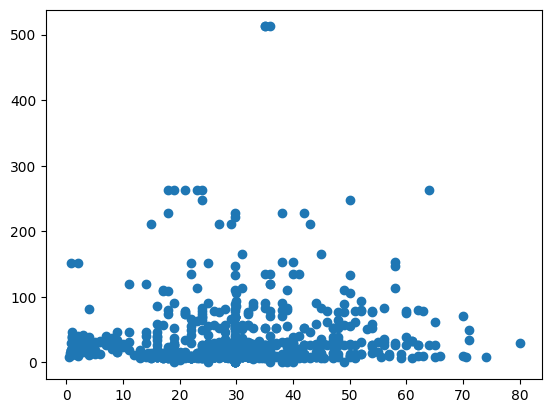

In [ ]:
plt.scatter(df["Age"], df["Fare"])

<Axes: >

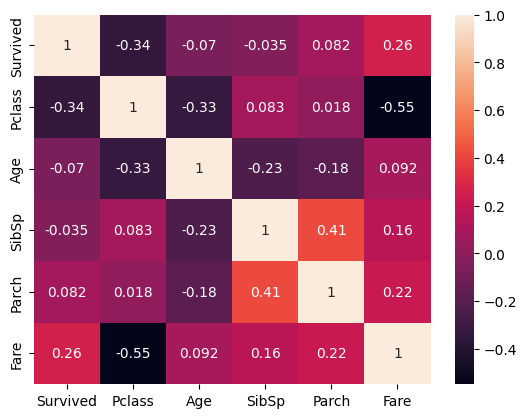

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex']).astype('int')
df['Embarked'] = le.fit_transform(df['Embarked']).astype('int')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.8 KB


<Axes: xlabel='Age', ylabel='Fare'>

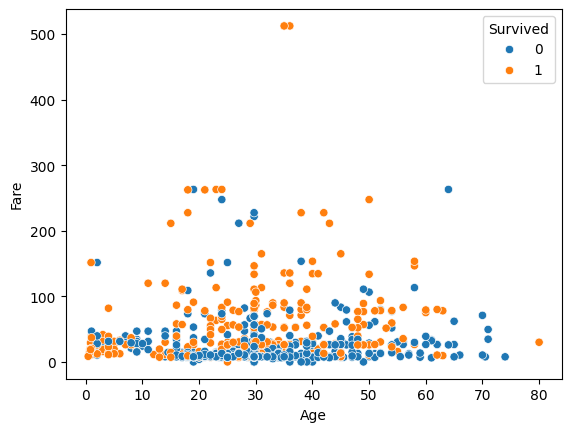

In [ ]:
sns.scatterplot(x=df["Age"], y=df["Fare"], hue=df["Survived"])

In [ ]:
X = df.drop(columns=["Survived"])
y = df["Survived"]

In [ ]:
y

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape,X_test.shape, y_train.shape, y_test.shape

((712, 7), (179, 7), (712,), (179,))

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

In [ ]:
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.8100558659217877
Confusion Matrix:
 [[90 15]
 [19 55]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_test_scaled

array([[ 0.81303367,  0.7243102 ,  0.01239022, ...,  0.78470001,
        -0.33390078, -2.01983093],
       [-0.40055118,  0.7243102 ,  0.11257046, ..., -0.47934164,
        -0.42528387,  0.55744438],
       [ 0.81303367,  0.7243102 , -0.73453348, ..., -0.47934164,
        -0.47486697,  0.55744438],
       ...,
       [ 0.81303367, -1.38062393,  0.6516366 , ...,  5.8408666 ,
        -0.02308312,  0.55744438],
       [-0.40055118, -1.38062393, -0.96556183, ..., -0.47934164,
        -0.42528387,  0.55744438],
       [ 0.81303367, -1.38062393, -1.96668467, ...,  0.78470001,
        -0.30589933,  0.55744438]])

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=3)

In [ ]:
knn_model.fit(X_train_scaled,y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
y_pred_knn = knn_model.predict(X_test_scaled)

In [ ]:
print("Accuracy Score :- ",accuracy_score(y_pred_knn,y_test))
print("Confusion matrix :- \n",confusion_matrix(y_pred_knn,y_test))
print("Classification Report :-\n",classification_report(y_pred_knn,y_test))

Accuracy Score :-  0.7932960893854749
Confusion matrix :- 
 [[88 20]
 [17 54]]
Classification Report :-
               precision    recall  f1-score   support

           0       0.84      0.81      0.83       108
           1       0.73      0.76      0.74        71

    accuracy                           0.79       179
   macro avg       0.78      0.79      0.79       179
weighted avg       0.80      0.79      0.79       179



<Axes: xlabel='Age', ylabel='Count'>

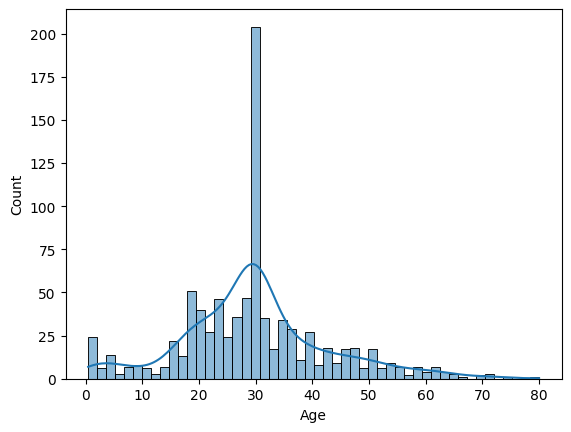

In [ ]:
sns.histplot(df["Age"], bins=50, kde=True)

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

In [ ]:
nb_model.fit(X_train,y_train)

GaussianNB()

In [ ]:
y_pred_nb = nb_model.predict(X_test)

In [ ]:
print("Accuracy Score :- ",accuracy_score(y_pred_nb,y_test))
print("Confusion matrix :- \n",confusion_matrix(y_pred_nb,y_test))
print("Classification Report :-\n",classification_report(y_pred_nb,y_test))

Accuracy Score :-  0.776536312849162
Confusion matrix :- 
 [[82 17]
 [23 57]]
Classification Report :-
               precision    recall  f1-score   support

           0       0.78      0.83      0.80        99
           1       0.77      0.71      0.74        80

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



In [ ]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(random_state=42)

model_dt.fit(X_train_scaled,y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_dt = model_dt.predict(X_test_scaled)

In [ ]:
print("Accuracy Score :- ",accuracy_score(y_pred_nb,y_test))
print("Confusion matrix :- \n",confusion_matrix(y_pred_nb,y_test))
print("Classification Report :-\n",classification_report(y_pred_nb,y_test))

Accuracy Score :-  0.776536312849162
Confusion matrix :- 
 [[82 17]
 [23 57]]
Classification Report :-
               precision    recall  f1-score   support

           0       0.78      0.83      0.80        99
           1       0.77      0.71      0.74        80

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



In [ ]:
from sklearn.svm import SVC

model_svm = SVC(kernel='rbf')

model_svm.fit(X_train_scaled, y_train)

SVC()

In [ ]:
y_pred_svm =   model_svm.predict(X_test_scaled)

In [ ]:
print("Accuracy Score :- ",accuracy_score(y_pred_svm,y_test))
print("Confusion matrix :- \n",confusion_matrix(y_pred_svm,y_test))
print("Classification Report :-\n",classification_report(y_pred_svm,y_test))

Accuracy Score :-  0.8156424581005587
Confusion matrix :- 
 [[93 21]
 [12 53]]
Classification Report :-
               precision    recall  f1-score   support

           0       0.89      0.82      0.85       114
           1       0.72      0.82      0.76        65

    accuracy                           0.82       179
   macro avg       0.80      0.82      0.81       179
weighted avg       0.82      0.82      0.82       179



In [ ]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [ ]:
X = df.drop(columns=["Survived"])
y = df["Survived"]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model_svm,X_scaled,y,cv=5,scoring='accuracy')

In [ ]:
scores

array([0.83240223, 0.82022472, 0.81460674, 0.80337079, 0.86516854])

In [ ]:
print(scores.mean())

0.827154604230745


In [ ]:
# grid search cv
# knn
# weights = ["uniform", "distance"]
# metric = ["euclidean", "manhattan", "minkowski"]

In [ ]:
# hyper parameter tunning using grid search

from sklearn.model_selection import GridSearchCV

classifier = GridSearchCV((model_svm),{
    'C': [1,10,20,30],
    'kernel': ['rbf', 'linear'],
    # 'gamma': ['scale', 'auto']
},cv = 5,return_train_score=False)

In [ ]:
classifier.fit(X,y)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [1, 10, 20, 30], 'kernel': ['rbf', 'linear']})

In [ ]:
classifier.cv_results_

{'mean_fit_time': array([2.99894810e-02, 4.58866830e+00, 1.55052185e-02, 1.90220078e+01,
        1.63926125e-02, 3.08800412e+01, 1.79267406e-02, 3.49984458e+01]),
 'std_fit_time': array([2.75617494e-03, 4.05902087e+00, 3.97146863e-04, 1.16591519e+01,
        4.52578016e-04, 7.91639295e+00, 5.75539732e-04, 1.23475847e+01]),
 'mean_score_time': array([0.01132669, 0.0033895 , 0.00486975, 0.00301619, 0.00487723,
        0.0040875 , 0.00541692, 0.00373106]),
 'std_score_time': array([1.65560406e-03, 8.17424718e-04, 2.50690958e-04, 6.61238187e-05,
        1.55142441e-04, 1.30273911e-03, 2.30416152e-04, 7.13578633e-04]),
 'param_C': masked_array(data=[1, 1, 10, 10, 20, 20, 30, 30],
              mask=[False, False, False, False, False, False, False, False],
        fill_value=999999),
 'param_kernel': masked_array(data=['rbf', 'linear', 'rbf', 'linear', 'rbf', 'linear',
                    'rbf', 'linear'],
              mask=[False, False, False, False, False, False, False, False],
        f

In [ ]:
results = pd.DataFrame(classifier.cv_results_)

In [ ]:
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.029989,0.002756,0.011327,0.001656,1,rbf,"{'C': 1, 'kernel': 'rbf'}",0.597765,0.713483,0.691011,0.685393,0.691011,0.675733,0.040160,8
1,4.588668,4.059021,0.003390,0.000817,1,linear,"{'C': 1, 'kernel': 'linear'}",0.804469,0.808989,0.786517,0.752809,0.786517,0.787860,0.019771,1
2,0.015505,0.000397,0.004870,0.000251,10,rbf,"{'C': 10, 'kernel': 'rbf'}",0.620112,0.730337,0.713483,0.730337,0.747191,0.708292,0.045360,7
3,19.022008,11.659152,0.003016,0.000066,10,linear,"{'C': 10, 'kernel': 'linear'}",0.804469,0.808989,0.786517,0.752809,0.786517,0.787860,0.019771,1
4,0.016393,0.000453,0.004877,0.000155,20,rbf,"{'C': 20, 'kernel': 'rbf'}",0.636872,0.735955,0.724719,0.735955,0.769663,0.720633,0.044511,6
5,30.880041,7.916393,0.004087,0.001303,20,linear,"{'C': 20, 'kernel': 'linear'}",0.804469,0.808989,0.786517,0.752809,0.786517,0.787860,0.019771,1
6,0.017927,0.000576,0.005417,0.000230,30,rbf,"{'C': 30, 'kernel': 'rbf'}",0.642458,0.775281,0.741573,0.764045,0.797753,0.744222,0.054011,5
7,34.998446,12.347585,0.003731,0.000714,30,linear,"{'C': 30, 'kernel': 'linear'}",0.804469,0.808989,0.786517,0.752809,0.786517,0.787860,0.019771,1


In [ ]:
results[["param_C","param_kernel","mean_test_score"]]

,param_C,param_kernel,mean_test_score
0,1,rbf,0.675733
1,1,linear,0.787860
2,10,rbf,0.708292
3,10,linear,0.787860
4,20,rbf,0.720633
5,20,linear,0.787860
6,30,rbf,0.744222
7,30,linear,0.787860


In [ ]:
classifier.best_params_

{'C': 1, 'kernel': 'linear'}

In [ ]:
classifier.best_score_

np.float64(0.7878601468834348)

In [ ]:
# hyper parameter tunning using random search

from sklearn.model_selection import RandomizedSearchCV

classifier_r = RandomizedSearchCV((model_svm),{
    'C': [1,10,20,30],
    'kernel': ['rbf', 'linear'],
    # 'gamma': ['scale', 'auto']
},n_iter=4,cv = 5,return_train_score=False)

In [ ]:
classifier_r.fit(X,y)

RandomizedSearchCV(cv=5, estimator=SVC(), n_iter=4,
                   param_distributions={'C': [1, 10, 20, 30],
                                        'kernel': ['rbf', 'linear']})

In [ ]:
classifier_r.cv_results_

{'mean_fit_time': array([3.53086181e+01, 1.94478872e+01, 1.74485683e-02, 4.97963018e+00]),
 'std_fit_time': array([1.28571889e+01, 1.16804440e+01, 5.26768973e-04, 4.70861119e+00]),
 'mean_score_time': array([0.00426607, 0.00333915, 0.00493722, 0.00325522]),
 'std_score_time': array([0.00086037, 0.00016671, 0.00021223, 0.00017129]),
 'param_kernel': masked_array(data=['linear', 'linear', 'rbf', 'linear'],
              mask=[False, False, False, False],
        fill_value=np.str_('?'),
             dtype=object),
 'param_C': masked_array(data=[30, 10, 30, 1],
              mask=[False, False, False, False],
        fill_value=999999),
 'params': [{'kernel': 'linear', 'C': 30},
  {'kernel': 'linear', 'C': 10},
  {'kernel': 'rbf', 'C': 30},
  {'kernel': 'linear', 'C': 1}],
 'split0_test_score': array([0.80446927, 0.80446927, 0.6424581 , 0.80446927]),
 'split1_test_score': array([0.80898876, 0.80898876, 0.7752809 , 0.80898876]),
 'split2_test_score': array([0.78651685, 0.78651685, 0.741573

In [ ]:
random = pd.DataFrame(classifier_r.cv_results_)

In [ ]:
random[["param_C","param_kernel","mean_test_score"]]

,param_C,param_kernel,mean_test_score
0,30,linear,0.787860
1,10,linear,0.787860
2,30,rbf,0.744222
3,1,linear,0.787860
